In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = ('/content/drive/MyDrive/DataScience Projects/mymoviedb.csv')
df=pd.read_csv(file_path ,lineterminator='\n', on_bad_lines='skip')

# --- LEVEL 1: EDA (Sorting & Counting) ---
# Highest Popularity
p_mv = df.sort_values(by="Popularity", ascending=False)
print("Highest Popularity Movie:")
display(p_mv[['Title', 'Genre', 'Popularity']].head(1).style.hide(axis='index'))








Highest Popularity Movie:


Title,Genre,Popularity
Spider-Man: No Way Home,"Action, Adventure, Science Fiction",5083.954000


In [19]:
# Most Frequent Genre (Top 5)
genre_counts = df['Genre'].value_counts().reset_index()
genre_counts.columns = ['Genre', 'Total_Movies']
print("\nTop 5 Frequent Genres:")
display(genre_counts.head(5).style.hide(axis='index'))



Top 5 Frequent Genres:


Genre,Total_Movies
Drama,466
Comedy,403
"Drama, Romance",248
Horror,238
"Horror, Thriller",199


In [20]:
# --- LEVEL 2: Filtering & Logic ---
# Hindi Movies
hindi_movies = df[df['Original_Language'] == 'hi']
print(f"\nTotal Hindi Movies: {hindi_movies.shape[0]}")
display(hindi_movies[['Title', 'Original_Language', 'Popularity']].head(5).style.hide(axis='index'))


Total Hindi Movies: 26


Title,Original_Language,Popularity
Looop Lapeta,hi,1240.946000
Sooryavanshi,hi,352.368000
Dhamaka,hi,121.718000
3 Idiots,hi,52.460000
Gangubai Kathiawadi,hi,50.682000


In [21]:
# Highest Rated (1000+ Votes condition)
valid_movies = df[df['Vote_Count'] > 1000]
top_rated = valid_movies.sort_values(by='Vote_Average', ascending=False).head(1)
print("\nHighest Rated Movie (1000+ Votes):")
display(top_rated[['Title', 'Vote_Average', 'Vote_Count', 'Genre']].style.hide(axis='index'))



Highest Rated Movie (1000+ Votes):


Title,Vote_Average,Vote_Count,Genre
The Godfather,8.700000,15614,"Drama, Crime"


/tmp/ipykernel_22526/1377456853.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Popularity', y='Genre', data=genre_analysis.head(10), palette='viridis')


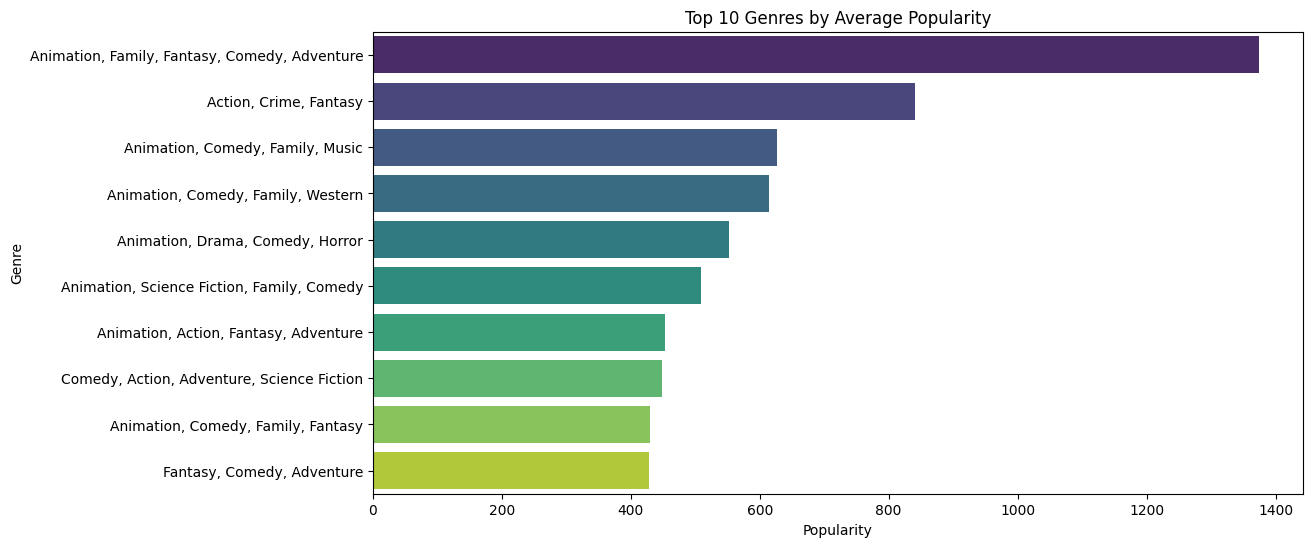

In [22]:
# --- LEVEL 3: Grouping & Visualization ---
# Genre vs Popularity
genre_analysis = df.groupby('Genre')['Popularity'].mean().reset_index().sort_values(by='Popularity', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Popularity', y='Genre', data=genre_analysis.head(10), palette='viridis')
plt.title('Top 10 Genres by Average Popularity')
plt.show()

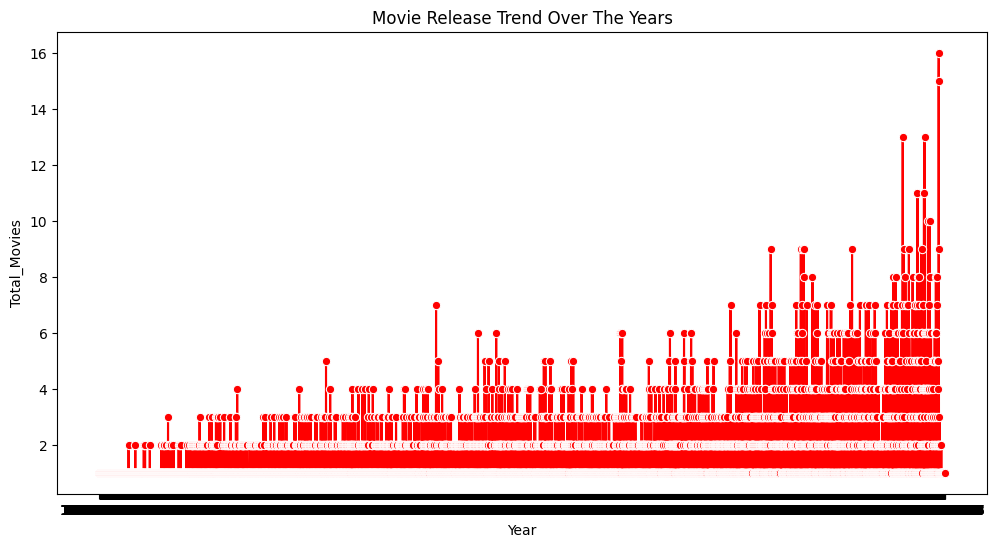

In [27]:

# Yearly Trend
yearly_trend = df.groupby('Release_Date')['Title'].count().reset_index()
yearly_trend.columns = ['Year', 'Total_Movies']

plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='Total_Movies', data=yearly_trend, marker='o', color='red')
plt.title('Movie Release Trend Over The Years')
plt.show()